# Machine learning fase 1 — Target Engineering

## Objetivo

Esta etapa tem como objetivo transformar o indicador exploratório `stress_score`,
desenvolvido durante a análise exploratória, em uma variável alvo (`target`)
adequada para a etapa de modelagem preditiva.

A pergunta central da análise preditiva é:

> As condições macroeconômicas observadas até o período t são capazes de
> antecipar um regime de estresse no período t+1?

Dessa forma, o problema será estruturado como:

X(t) → Stress(t+1)

O target será construído a partir do `stress_score` observado no período seguinte,
evitando que informações futuras sejam utilizadas como variáveis explicativas.

## Carregamento do Dataset

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CWD = Path.cwd().resolve()
if (CWD / "data" / "curated").exists():
    BASE = CWD
elif (CWD.parent / "data" / "curated").exists():
    BASE = CWD.parent
else:
    BASE = CWD

CURATED = BASE / "data" / "curated"
DATA_PATH = CURATED / "dataset_mvp.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset não encontrado: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").drop_duplicates("date").reset_index(drop=True)

df.head()

,date,ibc_br,selic,usd_brl,usd_brl_volatility,selic_change,usd_brl_return,ipca_12m,ipca_month,unemployment,...,icon_return_3m,icon_volatility_3m_ann,icon_drawdown,iee_return_1m,iee_return_3m,iee_volatility_3m_ann,iee_drawdown,ibc_br_change,pib_change_3m,unemployment_change
0,2012-01-31,NaN,10.50,1.7391,0.033688,NaN,NaN,NaN,NaN,NaN,...,0.096329,0.055734,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-02-29,NaN,10.50,1.7092,0.020402,0.00,-0.017193,6.22,0.56,NaN,...,0.172955,0.099694,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-03-31,97.32600,9.75,1.8221,0.030281,-0.75,0.066054,5.84,0.45,NaN,...,0.183501,0.086924,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-04-30,98.26784,9.00,1.8918,0.020445,-0.75,0.038253,5.24,0.21,8.0,...,0.158626,0.110466,0.000000,NaN,NaN,NaN,NaN,0.009677,NaN,NaN
4,2012-05-31,98.02892,8.50,2.0223,0.045587,-0.50,0.068982,5.10,0.64,7.8,...,-0.016764,0.222465,-0.077923,NaN,NaN,NaN,NaN,-0.002431,NaN,-0.2


## Preparação temporal

Como o objetivo é realizar uma previsão temporal, as observações devem ser
ordenadas cronologicamente.

Não serão utilizadas técnicas de embaralhamento das observações durante a
construção do target.

In [2]:
# Componentes e direção econômica esperada do estresse.
# +1: valores altos representam maior estresse.
# -1: valores baixos representam maior estresse.
stress_components = {
    "ibc_br_change": -1,
    "selic_change": 1,
    "usd_brl_return": 1,
    "usd_brl_volatility": 1,
    "ipca_12m": 1,
    "unemployment_change": 1,
    "pib_change_3m": -1,
}

stress_data = df[["date"]].copy() if "date" in df.columns else pd.DataFrame(index=df.index)

available_components = []
for column, direction in stress_components.items():
    if column not in df.columns:
        continue

    series = pd.to_numeric(df[column], errors="coerce")
    std = series.std()
    if pd.isna(std) or std == 0:
        continue

    stress_data[f"{column}_stress_z"] = (
        (series - series.mean()) / std
    ) * direction
    available_components.append(column)

stress_score_cols = [
    column for column in stress_data.columns
    if column.endswith("_stress_z")
]

if not stress_score_cols:
    raise ValueError(
        "Nenhum componente disponível para construir o stress_score."
    )

stress_data["stress_score"] = stress_data[stress_score_cols].mean(axis=1)
df = df.merge(
    stress_data[["date", "stress_score"]],
    on="date",
    how="left",
    validate="one_to_one",
)

print("Componentes utilizados:", available_components)
print("Coluna criada: stress_score")
display(df[["date", "stress_score"]].head())

Componentes utilizados: ['ibc_br_change', 'selic_change', 'usd_brl_return', 'usd_brl_volatility', 'ipca_12m', 'unemployment_change', 'pib_change_3m']
Coluna criada: stress_score


,date,stress_score
0,2012-01-31,-0.195754
1,2012-02-29,-0.368933
2,2012-03-31,-0.193526
3,2012-04-30,-0.602822
4,2012-05-31,0.031085


In [3]:
print("Primeira observação:", df["date"].min())
print("Última observação:", df["date"].max())
print("Número de observações:", len(df))

Primeira observação: 2012-01-31
Última observação: 2026-08-31
Número de observações: 176


## Validação do stress_score

O `stress_score` representa a intensidade relativa das condições de estresse
observadas no período.

Antes de utilizá-lo como base para o target preditivo, serão avaliados:

- valores ausentes;
- estatísticas descritivas;
- distribuição;
- comportamento temporal;
- existência de valores extremos.

In [4]:
df["stress_score"].describe()

count    176.000000
mean      -0.004509
std        0.443324
min       -1.161970
25%       -0.313286
50%       -0.050323
75%        0.275080
max        1.442375
Name: stress_score, dtype: float64

In [5]:
print("Valores ausentes:")
print(df["stress_score"].isna().sum())

print("\nValores únicos:")
print(df["stress_score"].nunique())

Valores ausentes:
0

Valores únicos:
176


## Visualizar o Stress Score

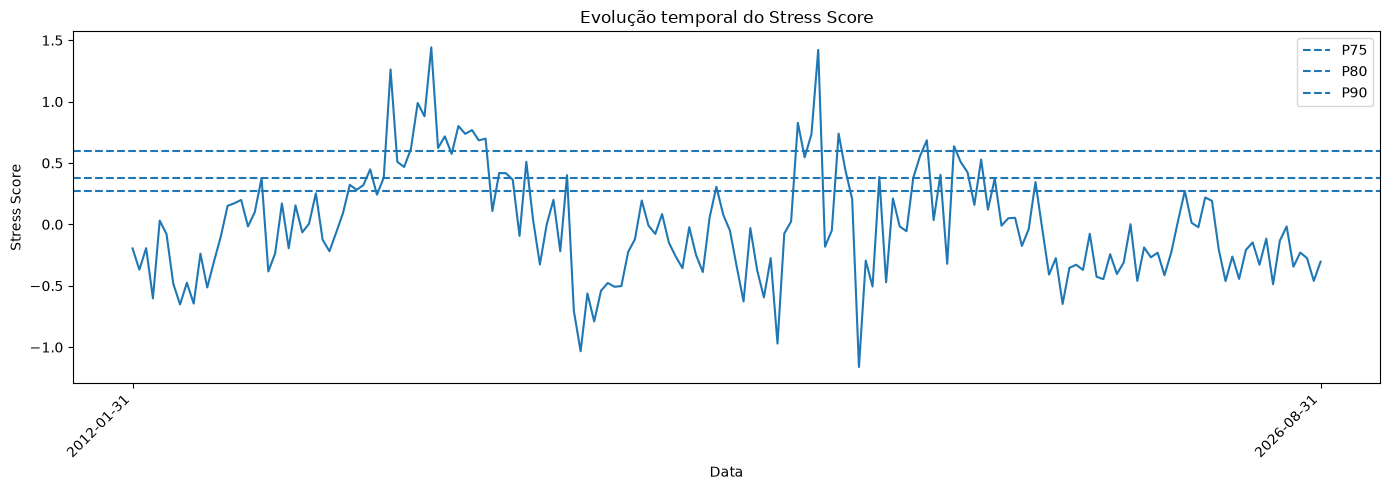

In [8]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["stress_score"]
)

plt.axhline(
    df["stress_score"].quantile(0.75),
    linestyle="--",
    label="P75"
)

plt.axhline(
    df["stress_score"].quantile(0.80),
    linestyle="--",
    label="P80"
)

plt.axhline(
    df["stress_score"].quantile(0.90),
    linestyle="--",
    label="P90"
)

plt.title("Evolução temporal do Stress Score")
plt.xlabel("Data")
plt.ylabel("Stress Score")

# Mantém apenas o primeiro e o último rótulo do eixo X
plt.xticks(
    [df["date"].iloc[0], df["date"].iloc[-1]],
    rotation=45,
    ha="right"
)

plt.legend()
plt.tight_layout()
plt.show()

## Definição dos thresholds candidatos

Como não existe, neste estágio, uma variável externa que determine
objetivamente quando a economia brasileira está em regime de estresse,
serão avaliados thresholds baseados na distribuição histórica do `stress_score`.

Serão considerados três cenários:

- P75 — identifica os 25% períodos de maior estresse;
- P80 — identifica os 20% períodos de maior estresse;
- P90 — identifica os 10% períodos de maior estresse.

A comparação entre essas alternativas permitirá avaliar o impacto da definição
do target sobre o balanceamento das classes e sobre a quantidade de eventos
disponíveis para treinamento.

In [9]:
thresholds = {
    "P75": df["stress_score"].quantile(0.75),
    "P80": df["stress_score"].quantile(0.80),
    "P90": df["stress_score"].quantile(0.90)
}

thresholds

{'P75': np.float64(0.27507994990533546),
 'P80': np.float64(0.3794480978713148),
 'P90': np.float64(0.5941575473811793)}

## Criar os targets "candidatos"

- Nosso objetivo é:

    Stress(t+1)

- e não:

    Stress(t)

In [11]:
for name, threshold in thresholds.items():
    df[f"target_{name.lower()}"] = (
        df["stress_score"].shift(-1) >= threshold
    ).astype("Int64")

## Validar o deslocamento temporal

In [13]:
validation = df[
    [
        "date",
        "stress_score",
        "target_p75",
        "target_p80",
        "target_p90"
    ]
].copy()

validation["stress_score_t1"] = df["stress_score"].shift(-1)

validation.head(10)

,date,stress_score,target_p75,target_p80,target_p90,stress_score_t1
0,2012-01-31,-0.195754,0,0,0,-0.368933
1,2012-02-29,-0.368933,0,0,0,-0.193526
2,2012-03-31,-0.193526,0,0,0,-0.602822
3,2012-04-30,-0.602822,0,0,0,0.031085
4,2012-05-31,0.031085,0,0,0,-0.078663
5,2012-06-30,-0.078663,0,0,0,-0.484383
6,2012-07-31,-0.484383,0,0,0,-0.652100
7,2012-08-31,-0.652100,0,0,0,-0.475280
8,2012-09-30,-0.475280,0,0,0,-0.645055
9,2012-10-31,-0.645055,0,0,0,-0.238905


In [14]:
df_ml = df.dropna(
    subset=["target_p75", "target_p80", "target_p90"]
).copy()

## Avaliar o balanceamento

Agora precisamos descobrir qual target é mais adequado.

Esperamos algo próximo de:

Target       Normal       Stress

P75          ~75%         ~25%
P80          ~80%         ~20%
P90          ~90%         ~10%

In [15]:
target_summary = []

for target in ["target_p75", "target_p80", "target_p90"]:
    
    counts = df_ml[target].value_counts().sort_index()
    percentages = df_ml[target].value_counts(normalize=True).sort_index() * 100
    
    target_summary.append({
        "target": target,
        "normal_count": counts.get(0, 0),
        "stress_count": counts.get(1, 0),
        "normal_pct": percentages.get(0, 0),
        "stress_pct": percentages.get(1, 0)
    })

target_summary = pd.DataFrame(target_summary)

target_summary

,target,normal_count,stress_count,normal_pct,stress_pct
0,target_p75,132,44,75.000000,25.000000
1,target_p80,140,36,79.545455,20.454545
2,target_p90,158,18,89.772727,10.227273


## Visualizar o balanceamento

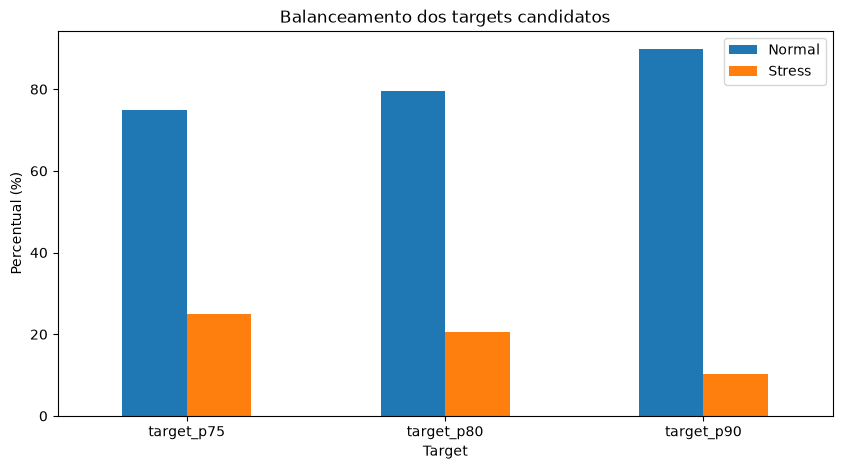

In [16]:
plot_df = target_summary.set_index("target")[
    ["normal_pct", "stress_pct"]
]

plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Balanceamento dos targets candidatos")
plt.xlabel("Target")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=0)
plt.legend(["Normal", "Stress"])
plt.show()

## Contar eventos de Stress

- Esse ponto é muito importante para a escolha do target.

    Não basta dizer:

    P90 é mais rigoroso.






- Precisamos perguntar:

    Temos eventos suficientes para treinar e testar um modelo?

In [17]:
for target in ["target_p75", "target_p80", "target_p90"]:
    
    stress_events = df_ml[target].sum()
    
    print(
        f"{target}: {stress_events} eventos de Stress"
    )

target_p75: 44 eventos de Stress
target_p80: 36 eventos de Stress
target_p90: 18 eventos de Stress


## Verificar a distribuição temporal dos eventos

Não queremos apenas saber quantos eventos existem.

Queremos saber quando eles aconteceram.

Isso permitirá verificar se os eventos estão:

- Distribuídos ao longo do histórico;
- Concentrados em determinados períodos;
- Excessivamente concentrados em uma única crise.

In [19]:
for target in ["target_p75", "target_p80", "target_p90"]:
    
    events = df_ml.loc[
        df_ml[target] == 1,
        ["date", target]
    ]
    
    print(f"\n{target}")
    print(events.to_string(index=False))


target_p75
      date  target_p75
2013-07-31           1
2014-08-31           1
2014-09-30           1
2014-10-31           1
2014-11-30           1
2015-01-31           1
2015-02-28           1
2015-03-31           1
2015-04-30           1
2015-05-31           1
2015-06-30           1
2015-07-31           1
2015-08-31           1
2015-09-30           1
2015-10-31           1
2015-11-30           1
2015-12-31           1
2016-01-31           1
2016-02-29           1
2016-03-31           1
2016-04-30           1
2016-06-30           1
2016-07-31           1
2016-08-31           1
2016-10-31           1
2017-04-30           1
2019-02-28           1
2020-02-29           1
2020-03-31           1
2020-04-30           1
2020-05-31           1
2020-08-31           1
2020-09-30           1
2021-02-28           1
2021-07-31           1
2021-08-31           1
2021-09-30           1
2021-11-30           1
2022-01-31           1
2022-02-28           1
2022-03-31           1
2022-05-31           1

## Visualizar os regimes

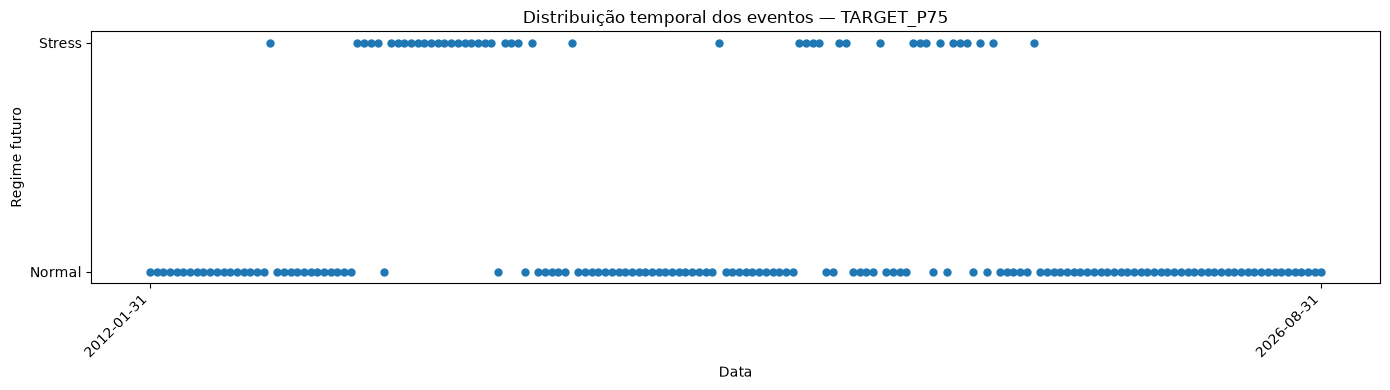

In [22]:
target = "target_p75"

plt.figure(figsize=(14, 4))

plt.scatter(
    df_ml["date"],
    df_ml[target],
    s=25
)

plt.yticks(
    [0, 1],
    ["Normal", "Stress"]
)

plt.title(
    f"Distribuição temporal dos eventos — {target.upper()}"
)

plt.xlabel("Data")
plt.ylabel("Regime futuro")

# Mantém apenas o primeiro e o último rótulo do eixo X
plt.xticks(
    [df_ml["date"].iloc[0], df_ml["date"].iloc[-1]],
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

## Critérios para definição do threshold de estresse

A definição do threshold para caracterização de um regime de estresse deve considerar critérios objetivos, evitando que a escolha seja baseada exclusivamente em uma determinada distribuição estatística.

### Critério 1 — Quantidade de eventos

O threshold deve produzir uma quantidade suficiente de eventos para permitir a divisão adequada dos dados entre:

- **Treinamento (Train)**
- **Validação (Validation)**
- **Teste (Test)**

Um número muito reduzido de eventos de estresse pode comprometer a capacidade do modelo de aprender e avaliar adequadamente esse regime.

### Critério 2 — Balanceamento das classes

Também deve ser avaliado o nível de desbalanceamento entre as classes.

Quanto maior o desbalanceamento, por exemplo:

- **95% — Normal**
- **5% — Stress**

maior tende a ser a dificuldade para avaliar corretamente o desempenho do modelo.

Por esse motivo, além das métricas tradicionais, a distribuição entre as classes deve ser considerada na definição do threshold.

### Critério 3 — Interpretabilidade

O threshold selecionado deve possuir uma interpretação econômica e operacional clara.

Idealmente, o regime de estresse deve representar:

> **Períodos excepcionalmente adversos do mercado.**

Dessa forma, o target não representa apenas uma classificação estatística, mas um evento que possui significado dentro do problema estudado.

### Critério 4 — Estabilidade temporal

Por fim, deve-se avaliar a distribuição temporal dos eventos identificados.

É importante evitar uma definição de target na qual praticamente todos os eventos de estresse estejam concentrados em uma única crise ou em um período muito específico.

Um target excessivamente concentrado pode fazer com que o modelo aprenda características particulares daquele episódio, reduzindo sua capacidade de generalização para outros períodos de estresse.

---

## Regra de decisão para definição do regime de estresse

Considerando os critérios apresentados, propõe-se inicialmente a avaliação de três thresholds alternativos:

| Threshold | Interpretação |
|---|---|
| **P75** | Candidato principal |
| **P80** | Candidato intermediário |
| **P90** | Cenário de estresse extremo |

Os três cenários serão mantidos durante a análise, permitindo comparar seus impactos sobre:

- quantidade de eventos;
- balanceamento das classes;
- distribuição temporal;
- interpretabilidade econômica;
- capacidade de treinamento e avaliação do modelo.

A definição final não será realizada exclusivamente com base no percentil escolhido, mas considerando conjuntamente esses diferentes critérios.

### Justificativa metodológica

Dessa forma, o trabalho avalia três definições alternativas de regime de estresse (**P75, P80 e P90**) e seleciona a definição final considerando simultaneamente a representatividade econômica do evento, o balanceamento das classes e a quantidade de observações disponível para treinamento e avaliação.

Essa abordagem é metodologicamente mais robusta do que simplesmente definir previamente um único threshold, pois permite demonstrar que a escolha do regime de estresse foi resultado de uma análise comparativa e fundamentada.

In [24]:
TARGET_THRESHOLD = thresholds["P75"]

next_score = df["stress_score"].shift(-1)
df["target_stress"] = (
    next_score.ge(TARGET_THRESHOLD) & next_score.notna()
).astype("Int64")

df_ml = df.loc[next_score.notna()].copy()

## Validar o target definitivo

In [25]:
df_ml[
    [
        "date",
        "stress_score",
        "target_stress"
    ]
].head(15)

,date,stress_score,target_stress
0,2012-01-31,-0.195754,0
1,2012-02-29,-0.368933,0
2,2012-03-31,-0.193526,0
3,2012-04-30,-0.602822,0
4,2012-05-31,0.031085,0
5,2012-06-30,-0.078663,0
6,2012-07-31,-0.484383,0
7,2012-08-31,-0.652100,0
8,2012-09-30,-0.475280,0
9,2012-10-31,-0.645055,0


In [26]:
print(
    df_ml["target_stress"]
    .value_counts()
    .sort_index()
)

target_stress
0    132
1     44
Name: count, dtype: Int64


## Salvar o Dataset

In [27]:
OUTPUT_PATH = Path(
    "../data/curated/dataset_ml_target.csv"
)

df_ml.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Dataset salvo em: {OUTPUT_PATH}")

Dataset salvo em: ..\data\curated\dataset_ml_target.csv


# Conclusões

Nesta etapa foi construída a variável alvo da análise preditiva a partir do
`stress_score` desenvolvido durante a análise exploratória.

O problema foi estruturado como uma previsão temporal:

X(t) → Stress(t+1)

Foram avaliados diferentes thresholds para caracterização do regime de
estresse, considerando os percentis P75, P80 e P90 da distribuição histórica
do `stress_score`.

A escolha do target definitivo considera três aspectos principais:

1. quantidade de eventos de estresse disponíveis;
2. balanceamento entre as classes;
3. representatividade temporal dos eventos.

O target selecionado será utilizado na etapa seguinte para construção das
variáveis explicativas e aplicação de técnicas de Machine Learning.

A principal preocupação metodológica desta etapa foi evitar o uso de
informações futuras na construção das variáveis explicativas.